In [1]:
%env MUJOCO_GL=egl
%env XLA_PYTHON_CLIENT_MEM_FRACTION=0.3

import sys, os
import numpy as np
import torch
import torch.utils.dlpack as tpack
import jax
import jax.numpy as jp
from etils import epath
import mujoco
import mediapy

from mujoco_playground import wrapper
from mujoco_playground._src import mjx_env
# from mujoco_playground._src.manipulation.airbot_play.pick import AirbotPlayPickCube, default_config
from mujoco_playground._src.manipulation.franka_emika_panda.pick import PandaPickCube, default_config

from discoverse.gaussian_renderer.batch_splat import BatchSplatConfig, BatchSplatRenderer

env: MUJOCO_GL=egl
env: XLA_PYTHON_CLIENT_MEM_FRACTION=0.3


In [2]:
# --- Load MJX env (replace with your env) ---
env = PandaPickCube(config=default_config())
num_envs = 512 # adjust
num_cams = env.mj_model.ncam
episode_length = int(4 / env._config.ctrl_dt)
rng = jax.random.PRNGKey(0)
env_wrap = wrapper.wrap_for_brax_training(env, vision=False, num_vision_envs=num_envs, episode_length=episode_length, action_repeat=1)

# Critical: JIT compile the environment step and reset functions
# Without JIT, the simulation runs in eager mode which is very slow
jit_reset = jax.jit(env_wrap.reset)
jit_step = jax.jit(env_wrap.step)

state = jit_reset(jax.random.split(rng, num_envs))
state = jit_step(state, jp.zeros((num_envs, env.mj_model.nu)))

print('Bodies:', env.mj_model.nbody, 'Cams:', env.mj_model.ncam)
for i in range(env.mj_model.nbody):
    print(env.mj_model.body(i).name, end=", ")

# print(state.data.qpos[0])
# print(state.data.xpos[0], state.data.xquat[0])
# print(state.data.cam_xpos[0].shape)

/home/tatp/miniconda3/envs/playground/lib/python3.10/site-packages/jax/_src/interpreters/xla.py:119: RuntimeWarning: overflow encountered in cast
  return np.asarray(x, dtypes.canonicalize_dtype(x.dtype))


Bodies: 14 Cams: 2
world, link0, link1, link2, link3, link4, link5, link6, link7, hand, left_finger, right_finger, box, mocap_target, 

In [ ]:
# --- Configure body->PLY mapping ---
# Update body names to match your MJCF; sample below assumes body name 'arm_base' exists.
Reso = "512"
ASSETS_PATH = mjx_env.ROOT_PATH / "manipulation/franka_emika_panda/3dgs"
body_gaussians = {
    # Add more bodies as needed
    "link0"         : (ASSETS_PATH / Reso / "link0.ply").as_posix(),
    "link1"         : (ASSETS_PATH / Reso / "link1.ply").as_posix(),
    "link2"         : (ASSETS_PATH / Reso / "link2.ply").as_posix(),
    "link3"         : (ASSETS_PATH / Reso / "link3.ply").as_posix(),
    "link4"         : (ASSETS_PATH / Reso / "link4.ply").as_posix(),
    "link5"         : (ASSETS_PATH / Reso / "link5.ply").as_posix(),
    "link6"         : (ASSETS_PATH / Reso / "link6.ply").as_posix(),
    "link7"         : (ASSETS_PATH / Reso / "link7.ply").as_posix(),
    "hand"          : (ASSETS_PATH / Reso / "hand.ply").as_posix(),
    "left_finger"   : (ASSETS_PATH / Reso / "left_finger.ply").as_posix(),
    "right_finger"  : (ASSETS_PATH / Reso / "right_finger.ply").as_posix(),
    "box"           : (ASSETS_PATH / "green_cube.ply").as_posix(),
}
cfg = BatchSplatConfig(body_gaussians=body_gaussians, background_ply=None, minibatch=256)
renderer = BatchSplatRenderer(cfg, mj_model=env.mj_model)
# configure renderer size
H = 120; W = 160

""

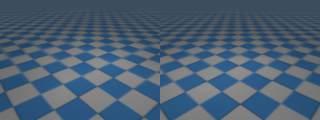

In [25]:
# mj_model = env.mj_model
mj_model = mujoco.MjModel.from_xml_path("/home/tatp/code/mujoco_playground/mujoco_playground/_src/manipulation/franka_emika_panda/xmls/mjx_single_cube.xml")
mj_data = mujoco.MjData(mj_model)
if mj_model.nkey:
    mujoco.mj_resetDataKeyframe(mj_model, mj_data, mj_model.key(0).id)
mujoco.mj_forward(mj_model, mj_data)

if 'mjr' in locals():
    mjr.close()
mjr = mujoco.Renderer(mj_model, height=H, width=W)
options = mujoco.MjvOption()
options.geomgroup[:] = 0
options.geomgroup[0] = 1
options.sitegroup[:] = 0
bg_imgs_gl = []
for i in range(num_cams):
    mjr.update_scene(mj_data, i, options)
    img = mjr.render().copy()
    bg_imgs_gl.append(img)
mediapy.show_image(np.hstack(bg_imgs_gl))

RGB: torch.Size([512, 2, 120, 160, 3]) Depth: torch.Size([512, 2, 120, 160, 1])


""

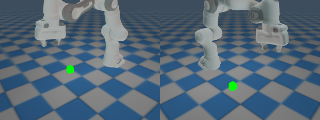

In [26]:
# --- Step 2: batch_update_gaussians ---
body_pos = tpack.from_dlpack(state.data.xpos)  # (Nenv, Nbody, 3)
body_quat = tpack.from_dlpack(state.data.xquat)  # (Nenv, Nbody, 4, wxyz)
gsb = renderer.batch_update_gaussians(body_pos, body_quat)
# --- Step 3: batch_env_render ---
cam_pos = tpack.from_dlpack(state.data.cam_xpos)   # (Nenv, Ncam, 3)
cam_xmat = tpack.from_dlpack(state.data.cam_xmat)   # (Nenv, Ncam, 3, 3)
fovy = np.array(env.mj_model.cam_fovy)[None, :]  # broadcast to (1, Ncam) or match cam count
bg_img = torch.ones((num_envs, num_cams, H, W, 3), dtype=torch.float32, requires_grad=False)
for i in range(num_cams):
    bg_img[:, i] = torch.from_numpy(bg_imgs_gl[i].astype(np.float32) / 255.0).unsqueeze(0).repeat(num_envs,1,1,1)
rgb, depth = renderer.batch_env_render(gsb, cam_pos, cam_xmat, H, W, fovy, bg_img)

print('RGB:', rgb.shape, 'Depth:', depth.shape)
mediapy.show_image(np.hstack(rgb[0,:].cpu().numpy()))

Avg update_gaussians: 23.57 ms
Avg render: 293.37 ms, width=160, height=120
Avg total: 316.93 ms, batch size=512
render fps = 3490.4952066175124
Done


""

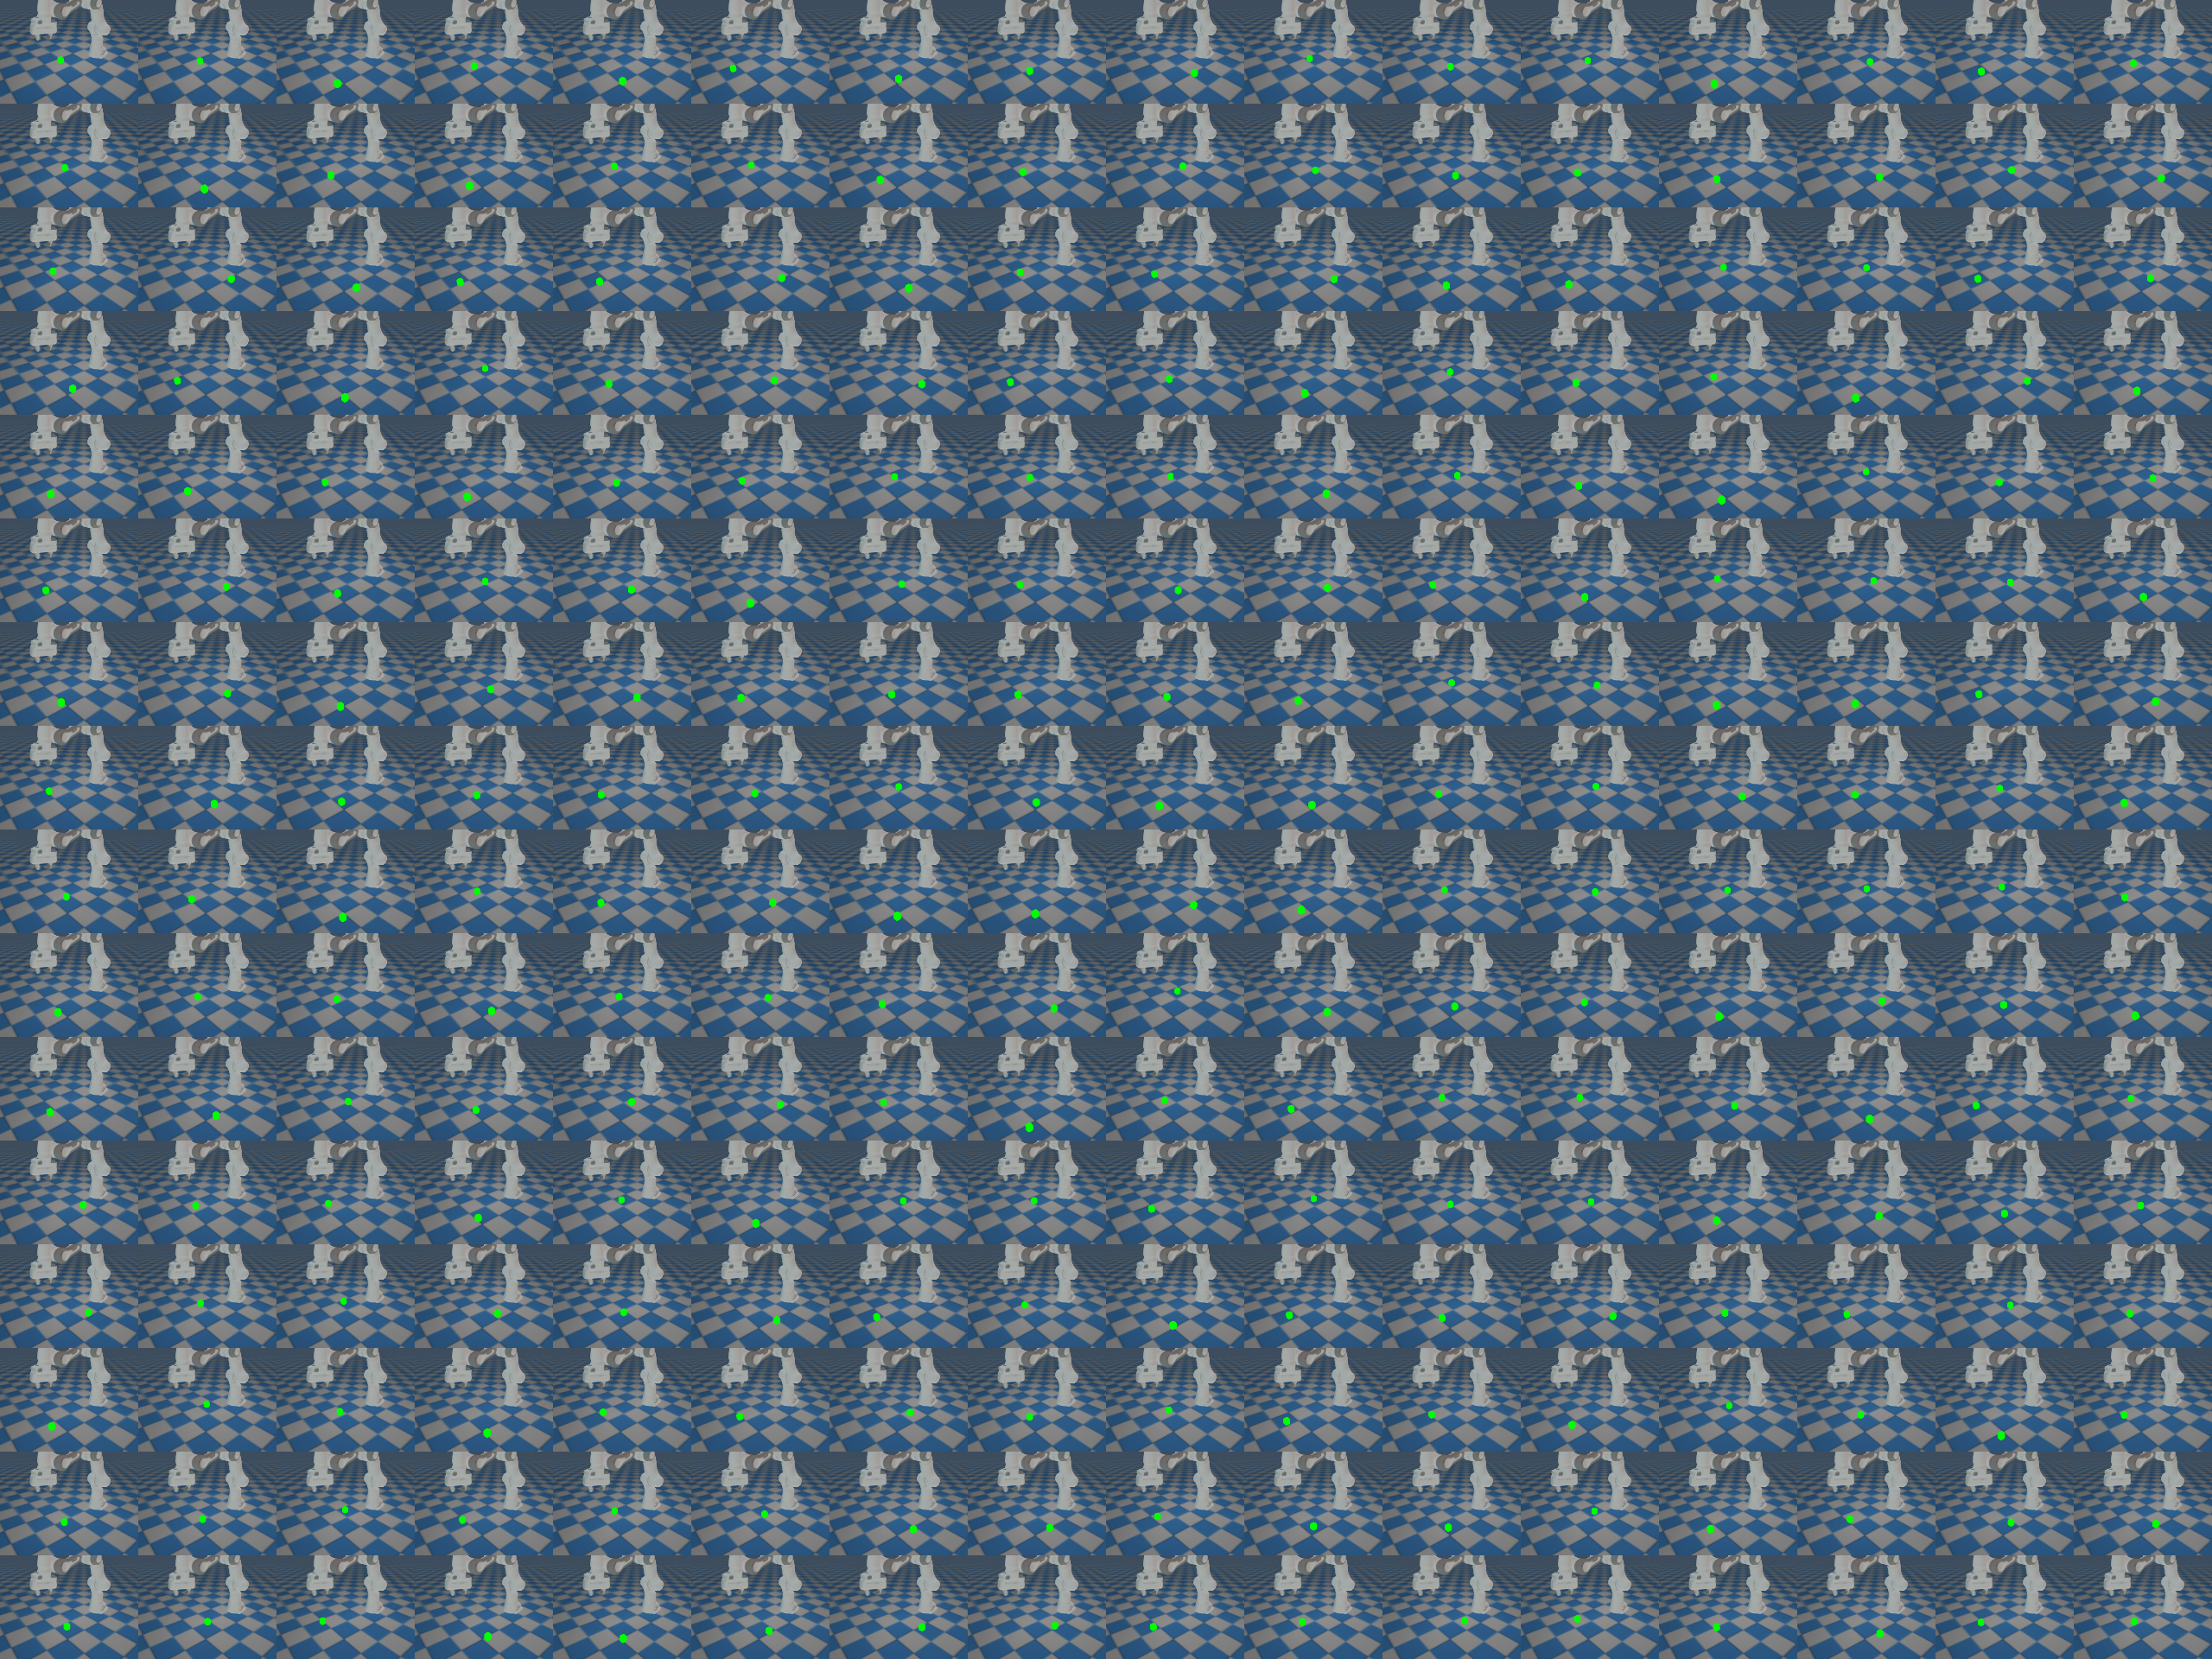

""

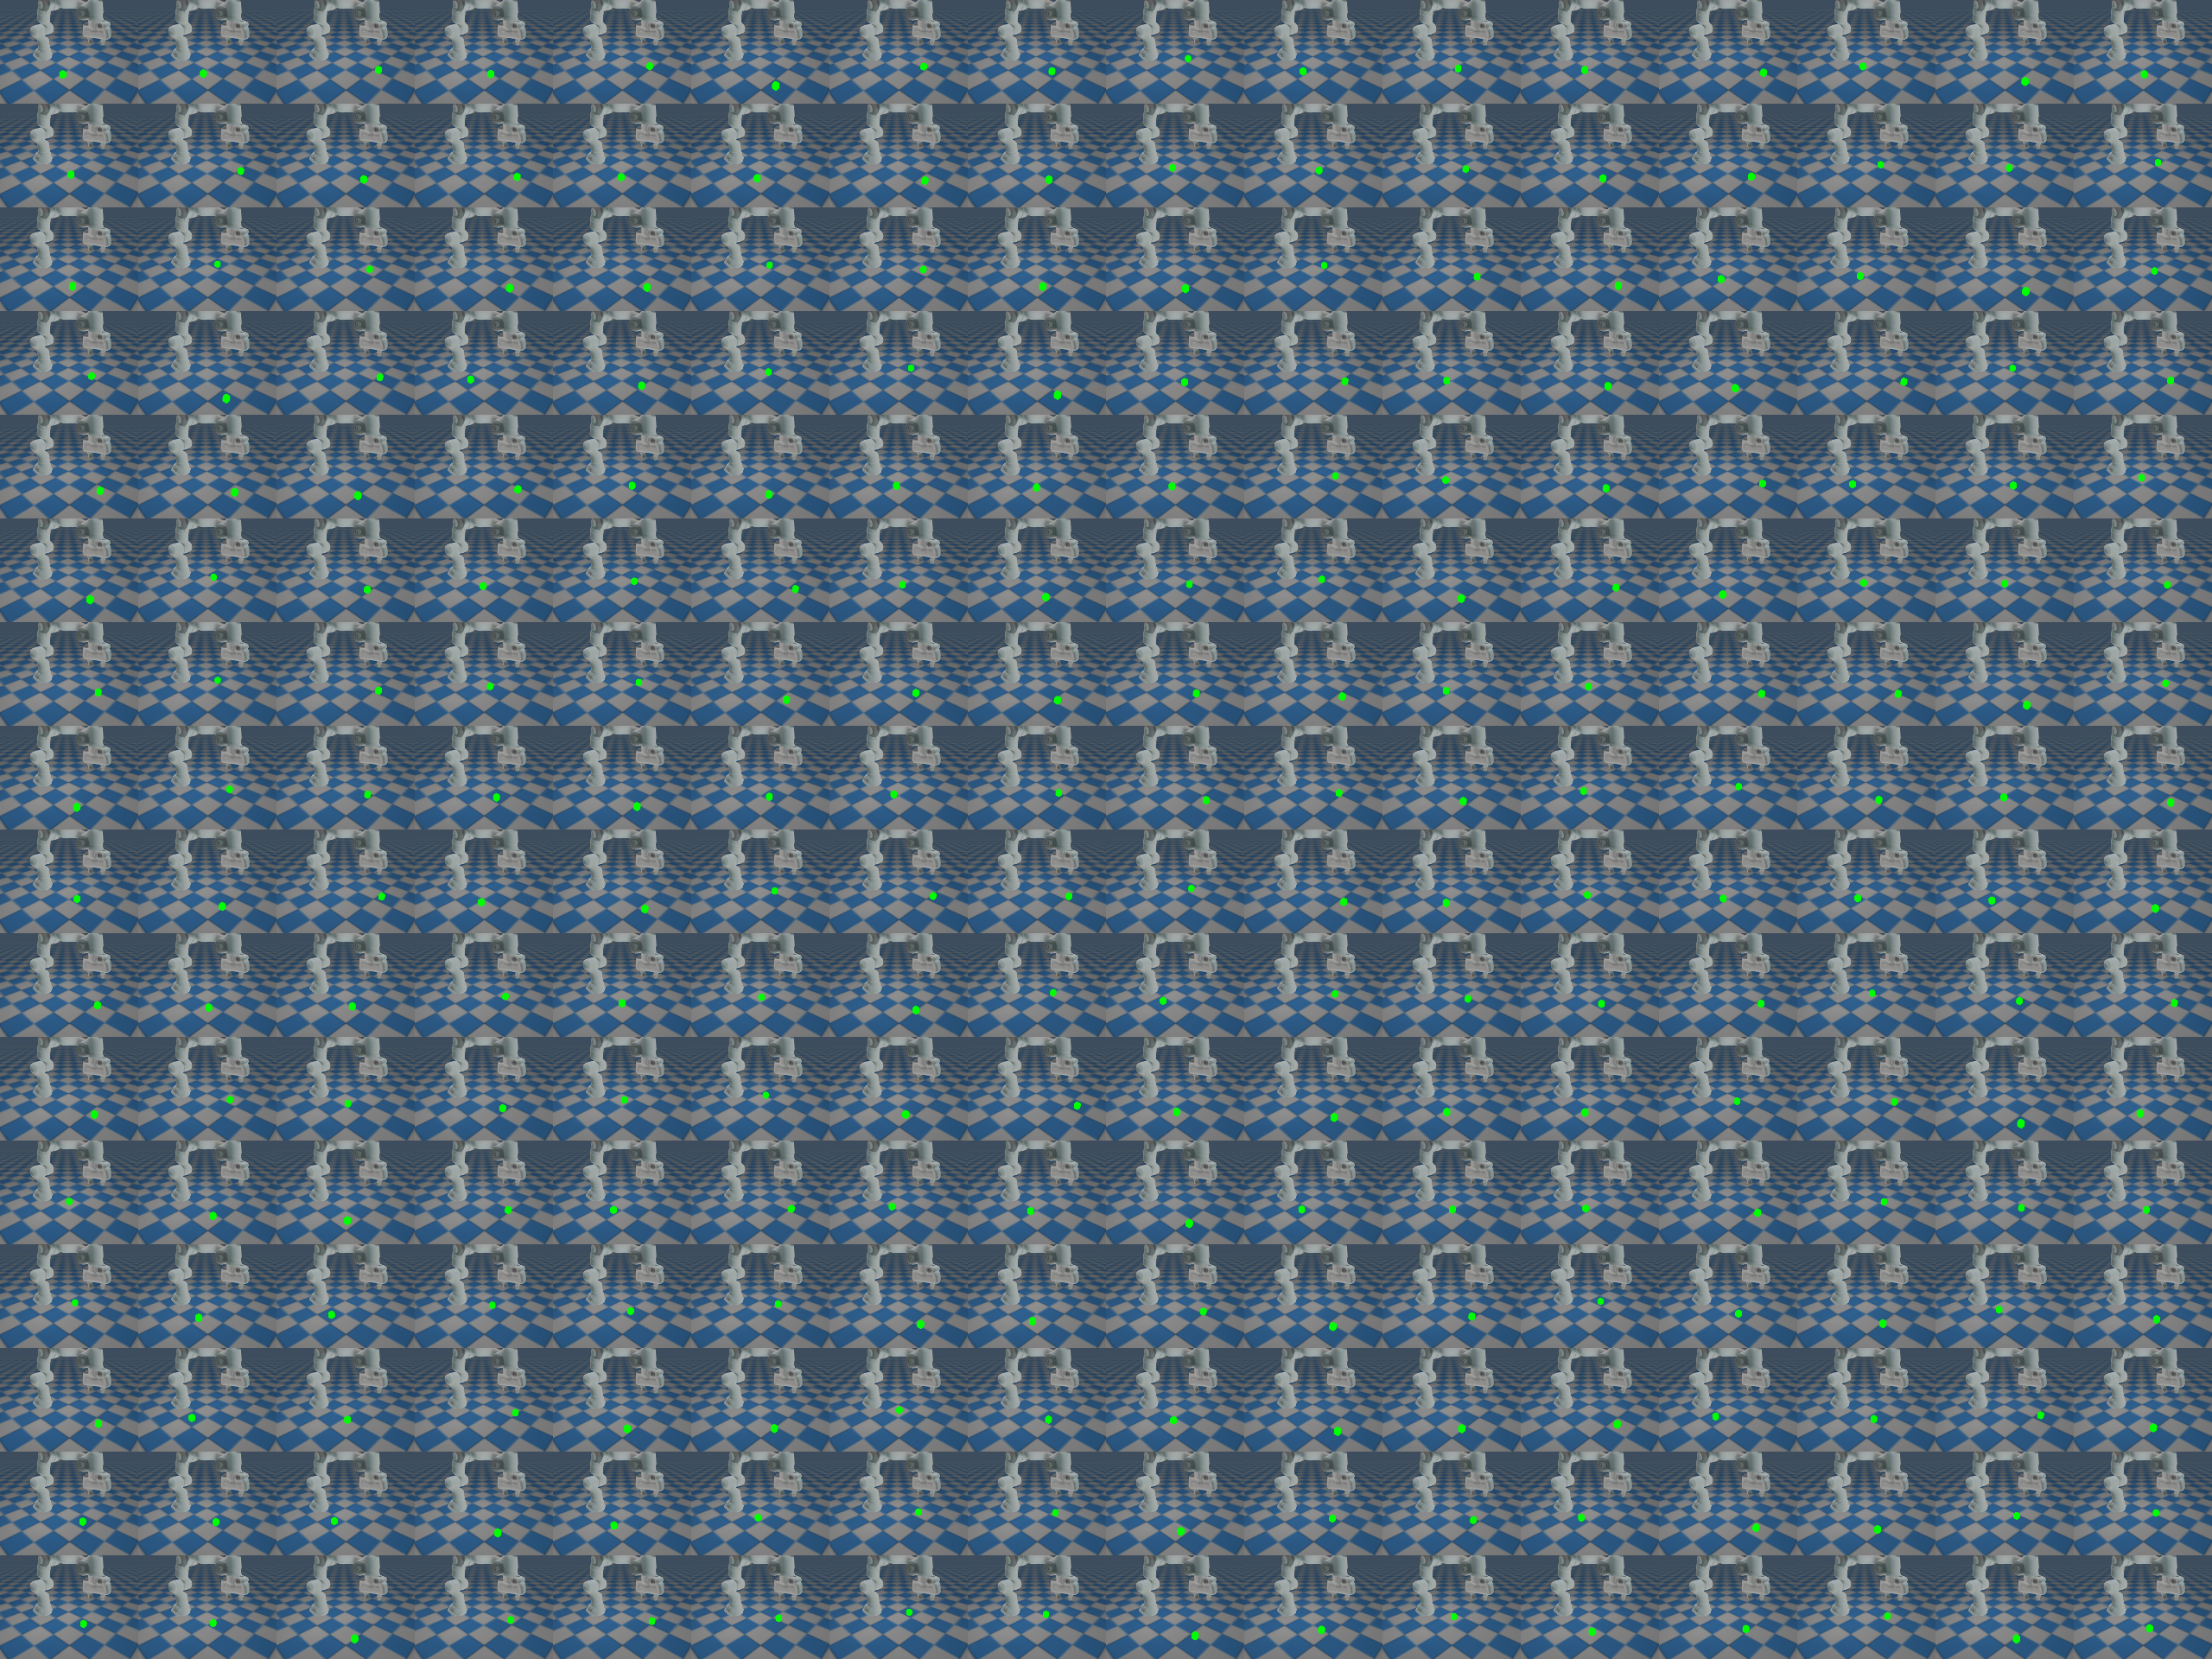

In [27]:
# --- Timing loop example (optional) ---
num_run = 10
gsb = renderer.batch_update_gaussians(body_pos, body_quat)
rgb, depth = renderer.batch_env_render(gsb, cam_pos, cam_xmat, H, W, fovy, bg_img)

torch.cuda.synchronize() if torch.cuda.is_available() else None
# 分别统计 update_gaussians 与 render 的用时
if torch.cuda.is_available():
    # 更新用时
    start_u = torch.cuda.Event(enable_timing=True)
    end_u = torch.cuda.Event(enable_timing=True)
    start_u.record()
    for _ in range(num_run):
        gsb = renderer.batch_update_gaussians(body_pos, body_quat)
    end_u.record(); end_u.synchronize()
    upd_ms = start_u.elapsed_time(end_u) / num_run

    # 渲染用时
    start_r = torch.cuda.Event(enable_timing=True)
    end_r = torch.cuda.Event(enable_timing=True)
    start_r.record()
    for _ in range(num_run):
        # rgb, depth = renderer.batch_env_render(gsb, cam_pos, cam_xmat, H, W, fovy)
        rgb, depth = renderer.batch_env_render(gsb, cam_pos, cam_xmat, H, W, fovy, bg_img)
    end_r.record(); end_r.synchronize()
    ren_ms = start_r.elapsed_time(end_r) / num_run
else:
    raise NotImplementedError("Timing code only implemented for CUDA.")

print(f'Avg update_gaussians: {upd_ms:.2f} ms')
print(f'Avg render: {ren_ms:.2f} ms, width={W}, height={H}')
print(f'Avg total: {upd_ms + ren_ms:.2f} ms, batch size={body_pos.shape[0]}')
print(f"render fps = {1e3 * np.prod(rgb.shape[:2]) / ren_ms}")
print('Done')

def tile(img, d):
    assert img.shape[0] == d*d
    img = img.reshape((d,d)+img.shape[1:])
    return np.concat(np.concat(img, axis=1), axis=1)
    
img_arr = rgb.detach().cpu().numpy()
for i in range(img_arr.shape[1]):
    mediapy.show_image(tile(img_arr[:256,i,...], 16))